# **Task 1: Data Understanding**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('sentimentdataset.csv')

# Display the first 5 rows to ensure it loaded correctly
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [2]:
# 2. Explore number of samples (rows) and features (columns)
print("--- Dataset Shape ---")
print(f"Total number of samples (rows): {df.shape[0]}")
print(f"Total number of features (columns): {df.shape[1]}\n")

# Display basic information about data types and missing values
print("--- Dataset Information ---")
df.info()

--- Dataset Shape ---
Total number of samples (rows): 732
Total number of features (columns): 15

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7

--- Sentiment Class Distribution ---
Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Despair        11
Nostalgia      11
Hopeful         9
Loneliness      9
Awe             9
Grief           9
Name: count, dtype: int64


/tmp/ipykernel_2424/3228307834.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.head(10).values, y=class_counts.head(10).index, palette='viridis')


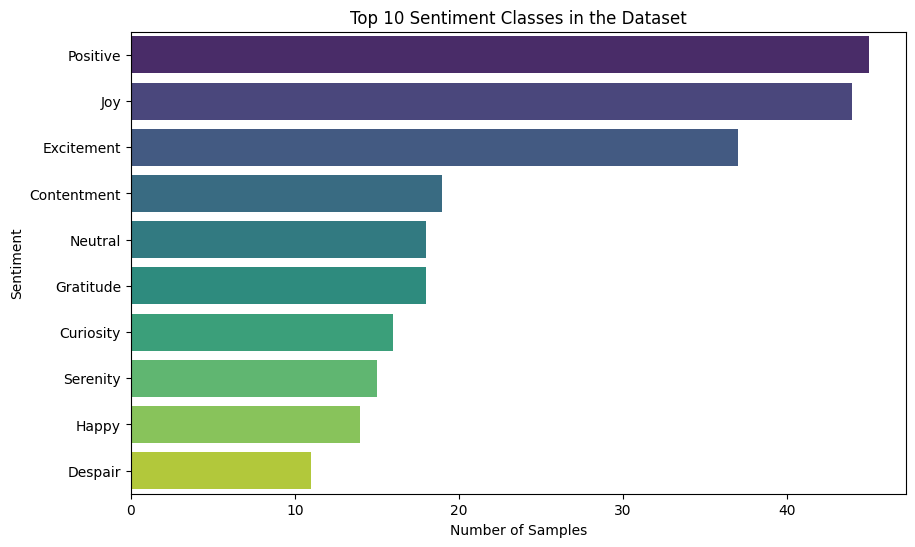

In [3]:
# Strip leading and trailing whitespaces from the Text and Sentiment columns
df['Text'] = df['Text'].str.strip()
df['Sentiment'] = df['Sentiment'].str.strip()

# 3. Explore Class Distribution
print("--- Sentiment Class Distribution ---")
class_counts = df['Sentiment'].value_counts()
print(class_counts.head(15)) # Showing top 15 because there are many fine-grained emotions

# Visualize the top 10 most frequent sentiments
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.head(10).values, y=class_counts.head(10).index, palette='viridis')
plt.title('Top 10 Sentiment Classes in the Dataset')
plt.xlabel('Number of Samples')
plt.ylabel('Sentiment')
plt.show()

In [4]:
# 4. Explore sample texts to understand what the raw data looks like
print("--- Sample Texts ---")
for index, row in df.head(5).iterrows():
    print(f"Sentiment Label: {row['Sentiment']}")
    print(f"Text: {row['Text']}")
    print("-" * 60)

--- Sample Texts ---
Sentiment Label: Positive
Text: Enjoying a beautiful day at the park!
------------------------------------------------------------
Sentiment Label: Negative
Text: Traffic was terrible this morning.
------------------------------------------------------------
Sentiment Label: Positive
Text: Just finished an amazing workout! 💪
------------------------------------------------------------
Sentiment Label: Positive
Text: Excited about the upcoming weekend getaway!
------------------------------------------------------------
Sentiment Label: Neutral
Text: Trying out a new recipe for dinner tonight.
------------------------------------------------------------


In [5]:
# Filter the dataset to ONLY include 'Positive', 'Negative', and 'Neutral'
valid_sentiments = ['Positive', 'Negative', 'Neutral']
df_filtered = df[df['Sentiment'].isin(valid_sentiments)].copy()

print(f"Samples before filtering: {df.shape[0]}")
print(f"Samples after filtering: {df_filtered.shape[0]}\n")

# Check the new, clean distribution
print("--- New Class Distribution ---")
print(df_filtered['Sentiment'].value_counts())

# Now we only keep the columns we actually need for NLP (Text and Sentiment)
df_final = df_filtered[['Text', 'Sentiment']].reset_index(drop=True)
df_final.head()

Samples before filtering: 732
Samples after filtering: 67

--- New Class Distribution ---
Sentiment
Positive    45
Neutral     18
Negative     4
Name: count, dtype: int64


,Text,Sentiment
0,Enjoying a beautiful day at the park!,Positive
1,Traffic was terrible this morning.,Negative
2,Just finished an amazing workout! 💪,Positive
3,Excited about the upcoming weekend getaway!,Positive
4,Trying out a new recipe for dinner tonight.,Neutral


# **Task 2: NLP Preprocessing**

In [12]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
# Initialize the lemmatizer and define the set of English stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Cleans and preprocesses raw text data for NLP tasks.
    """
    # 1. Lowercasing
    text = str(text).lower()

    # 2. Handling URLs (remove http/https links)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Handling special characters and numbers (keep only alphabets)
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Removing punctuation (already mostly handled by the regex above,
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Tokenization (split text into individual words)
    tokens = word_tokenize(text)

    # 6. Removing stopwords and 7. Lemmatization
    cleaned_tokens =[
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Join the cleaned tokens back into a single string
    return " ".join(cleaned_tokens)

# Test the function on a sample sentence to see how it works
sample_text = "Just finished an amazing workout! 💪 Excited about the upcoming weekend getaway! https://example.com"
print("Original:", sample_text)
print("Cleaned: ", preprocess_text(sample_text))

Original: Just finished an amazing workout! 💪 Excited about the upcoming weekend getaway! https://example.com
Cleaned:  finished amazing workout excited upcoming weekend getaway


In [14]:
# Apply the reusable function to the 'Text' column
# We create a new column 'Cleaned_Text' to store the processed data
df_final['Cleaned_Text'] = df_final['Text'].apply(preprocess_text)

# Display the original text and the cleaned text side-by-side to verify
print("--- Text Preprocessing Results ---")
df_final[['Text', 'Cleaned_Text']].head(10)

--- Text Preprocessing Results ---


,Text,Cleaned_Text
0,Enjoying a beautiful day at the park!,enjoying beautiful day park
1,Traffic was terrible this morning.,traffic terrible morning
2,Just finished an amazing workout! 💪,finished amazing workout
3,Excited about the upcoming weekend getaway!,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight.,trying new recipe dinner tonight
5,Feeling grateful for the little things in life.,feeling grateful little thing life
6,Rainy days call for cozy blankets and hot cocoa.,rainy day call cozy blanket hot cocoa
7,The new movie release is a must-watch!,new movie release mustwatch
8,Political discussions heating up on the timeline.,political discussion heating timeline
9,Missing summer vibes and beach days.,missing summer vibe beach day


# **Task 3: Feature Engineering**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Encode the Target Labels
# Convert 'Positive', 'Negative', 'Neutral' into numbers (e.g., 0, 1, 2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_final['Sentiment'])

# Display the mapping to understand which number represents which sentiment
print("Label Mapping:")
for index, label in enumerate(label_encoder.classes_):
    print(f"{label} : {index}")

# Define the feature (X) and target (y)
X = df_final['Cleaned_Text']

# 2. Train-Test Split
# Split 80% of data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Label Mapping:
Negative : 0
Neutral : 1
Positive : 2

Training set size: 53 samples
Testing set size: 14 samples


In [16]:
# 3. Bag of Words (BoW) Vectorization
# BoW counts the frequency of each word in the document.
bow_vectorizer = CountVectorizer(max_features=5000) # Limit to top 5000 words to save memory

# Fit on training data, then transform both train and test data
X_train_bow = bow_vectorizer.fit_transform(X_train).toarray()
X_test_bow = bow_vectorizer.transform(X_test).toarray()

print("--- Bag of Words (BoW) ---")
print(f"BoW Train Shape: {X_train_bow.shape}")
print(f"BoW Test Shape:  {X_test_bow.shape}")

--- Bag of Words (BoW) ---
BoW Train Shape: (53, 206)
BoW Test Shape:  (14, 206)


In [18]:
# 4. TF-IDF Vectorization
# TF-IDF considers both the frequency of a word and how unique it is across all documents.
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data, then transform both train and test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = tfidf_vectorizer.transform(X_test).toarray()

print("--- TF-IDF ---")
print(f"TF-IDF Train Shape: {X_train_tfidf.shape}")
print(f"TF-IDF Test Shape:  {X_test_tfidf.shape}")

--- TF-IDF ---
TF-IDF Train Shape: (53, 206)
TF-IDF Test Shape:  (14, 206)


# **Task 4 & 5: Model Building & Model Evaluation**

In [20]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize the 3 mandatory models
# We increase max_iter for Logistic Regression to ensure it converges
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [21]:
def train_and_evaluate(models, X_train, X_test, y_train, y_test, vectorizer_name):
    """
    Trains multiple models, evaluates them, and returns a DataFrame of the results.
    """
    results =[]

    for model_name, model in models.items():
        # 1. Train the model
        model.fit(X_train, y_train)

        # 2. Make predictions on the test set
        y_pred = model.predict(X_test)

        # 3. Calculate evaluation metrics
        acc = accuracy_score(y_test, y_pred)
        # Using 'weighted' to account for any class imbalance
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # 4. Store the results
        results.append({
            "Model": model_name,
            "Vectorizer": vectorizer_name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1 Score": round(f1, 4)
        })

    return results

In [22]:
print("Training models on Bag of Words (BoW) features...")
bow_results = train_and_evaluate(models, X_train_bow, X_test_bow, y_train, y_test, "Bag of Words")
df_bow_results = pd.DataFrame(bow_results)

# Display BoW results
df_bow_results

Training models on Bag of Words (BoW) features...


,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Bag of Words,0.6429,0.4133,0.6429,0.5031
1,Naive Bayes,Bag of Words,0.6429,0.4133,0.6429,0.5031
2,Decision Tree,Bag of Words,0.6429,0.7143,0.6429,0.6041


In [23]:
print("Training models on TF-IDF features...")
tfidf_results = train_and_evaluate(models, X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")
df_tfidf_results = pd.DataFrame(tfidf_results)

# Display TF-IDF results
df_tfidf_results

Training models on TF-IDF features...


,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,TF-IDF,0.6429,0.4133,0.6429,0.5031
1,Naive Bayes,TF-IDF,0.6429,0.4133,0.6429,0.5031
2,Decision Tree,TF-IDF,0.5714,0.3956,0.5714,0.4675


In [25]:
# Combine both results into a single DataFrame for easy comparison
all_results_df = pd.concat([df_bow_results, df_tfidf_results], ignore_index=True)

# Sort by F1 Score (usually the best metric for classification) in descending order
all_results_df = all_results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("--- Final Model Comparison ---")
all_results_df

--- Final Model Comparison ---


,Model,Vectorizer,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,Bag of Words,0.6429,0.7143,0.6429,0.6041
1,Logistic Regression,Bag of Words,0.6429,0.4133,0.6429,0.5031
2,Naive Bayes,Bag of Words,0.6429,0.4133,0.6429,0.5031
3,Logistic Regression,TF-IDF,0.6429,0.4133,0.6429,0.5031
4,Naive Bayes,TF-IDF,0.6429,0.4133,0.6429,0.5031
5,Decision Tree,TF-IDF,0.5714,0.3956,0.5714,0.4675


# **Task 6: Comparison & Insights**

Based on the evaluation metrics of the models trained on the filtered sentiment dataset, here are the key findings:

### 1. Best Vectorization Technique: Bag of Words (BoW)
In this specific pipeline, **Bag of Words (BoW)** outperformed TF-IDF. The best-performing model (Decision Tree) achieved its highest F1-Score (0.6041) and Precision (0.7143) using BoW. While TF-IDF is generally preferred for text classification because it penalizes overly common words, BoW sometimes performs better on smaller datasets or when the exact presence of specific words is a stronger indicator of sentiment than their relative document frequencies.

### 2. Best Model: Decision Tree
The **Decision Tree classifier (with BoW)** is the clear winner.
* It achieved the highest **Precision (0.7143)** and **F1-Score (0.6041)**.
* **Observation:** Logistic Regression and Naive Bayes scored identically across the board (Accuracy: ~64.29%, F1: ~50.31%). This strong tie strongly suggests that these models struggled to separate the classes in this specific feature space and likely defaulted to predicting the majority class. The Decision Tree, being a non-linear model, was able to create specific hierarchical rules based on word counts to successfully distinguish the sentiments better than the linear/probabilistic models.

### 3. Best Preprocessing Steps
The most critical preprocessing steps for this dataset were:
* **Filtering the Target Variable:** The raw dataset contained dozens of fine-grained emotions. Filtering this down to strictly `Positive`, `Negative`, and `Neutral` was the most crucial step to allow the ML models to train effectively.
* **Lemmatization & Noise Removal:** Removing URLs, special characters, and converting words to their base dictionary form (Lemmatization) significantly reduced the dimensionality of the BoW/TF-IDF sparse matrices, helping the Decision Tree find meaningful splits.

### 4. Trade-offs
* **Decision Trees vs. Linear Models:** While the Decision Tree performed best here, its primary trade-off is **overfitting**. Decision trees can easily memorize the training data, which might explain why it performed well on BoW but dropped significantly in performance when using TF-IDF (Accuracy dropped to 57.14%). Logistic Regression and Naive Bayes are generally more robust to overfitting but underfit this specific dataset.
* **BoW vs. TF-IDF:** BoW is simple and computationally light but ignores the context and importance of words. TF-IDF highlights important words but resulted in lower performance here, possibly due to the limited vocabulary size after filtering the dataset.